question 1

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [7]:
import os

print(os.getcwd())

c:\Users\purva kose\OneDrive\Desktop\laptop_assignment25\notebook


In [8]:
import os

print(os.listdir())

['Laptop_Price_Prediction.ipynb']


In [10]:
df = pd.read_csv("../dataset/laptop_price.csv", encoding="cp1252")

In [11]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [12]:
print("Shape of Dataset :", df.shape)
print()

print("Column Names:")
print(df.columns.tolist())

print()

df.info()

Shape of Dataset : (1303, 13)

Column Names:
['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros']

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: fl

In [13]:
print("Missing Values")
print("-" * 30)

print(df.isnull().sum())

Missing Values
------------------------------
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [ ]:
df.drop("laptop_ID", axis=1, inplace=True)
print("Column Removed Successfully")

Column Removed Successfully


In [15]:
df["Ram"] = df["Ram"].str.replace("GB", "", regex=False)
df["Ram"] = df["Ram"].astype(int)

df["Weight"] = df["Weight"].str.replace("kg", "", regex=False)
df["Weight"] = df["Weight"].astype(float)

df[["Ram", "Weight"]].head()

,Ram,Weight
0,8,1.37
1,8,1.34
2,8,1.86
3,16,1.83
4,8,1.37


In [16]:
encoders = {}

categorical_cols = [
    "Company",
    "Product",
    "TypeName",
    "ScreenResolution",
    "Cpu",
    "Memory",
    "Gpu",
    "OpSys"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [25]:
joblib.dump(encoders, "encoders.pkl")

print("Encoders Saved Successfully")

Encoders Saved Successfully


In [19]:
X = df.drop("Price_euros", axis=1)
y = df["Price_euros"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1303, 11)
Target Shape : (1303,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (1042, 11)
Testing Data : (261, 11)


In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [22]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [23]:
import os

print("encoders.pkl Exists :", os.path.exists("encoders.pkl"))
print("scaler.pkl Exists :", os.path.exists("scaler.pkl"))

encoders.pkl Exists : True
scaler.pkl Exists : True


question 2

In [26]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [27]:
kernels = ["linear", "rbf"]
c_values = [1, 10, 20]

best_score = -999
best_kernel = None
best_C = None
best_model = None

In [28]:
for kernel in kernels:
    for c in c_values:

        model = SVR(kernel=kernel, C=c)

        model.fit(X_train, y_train)

        prediction = model.predict(X_test)

        score = r2_score(y_test, prediction)

        print(f"Kernel={kernel}, C={c}, R²={score:.4f}")

        if score > best_score:
            best_score = score
            best_kernel = kernel
            best_C = c
            best_model = model

Kernel=linear, C=1, R²=0.5531
Kernel=linear, C=10, R²=0.6226
Kernel=linear, C=20, R²=0.6261
Kernel=rbf, C=1, R²=0.0323
Kernel=rbf, C=10, R²=0.3148
Kernel=rbf, C=20, R²=0.3988


In [29]:
print("=" * 45)
print("Best Kernel :", best_kernel)
print("Best C Value :", best_C)
print("Highest R² Score :", round(best_score, 4))
print("=" * 45)

Best Kernel : linear
Best C Value : 20
Highest R² Score : 0.6261


In [30]:
svr_prediction = best_model.predict(X_test)

In [31]:
svr_r2 = r2_score(y_test, svr_prediction)
svr_mae = mean_absolute_error(y_test, svr_prediction)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_prediction))

print("SVR Results")
print("-" * 30)
print("R² Score :", round(svr_r2, 4))
print("MAE :", round(svr_mae, 2))
print("RMSE :", round(svr_rmse, 2))

SVR Results
------------------------------
R² Score : 0.6261
MAE : 285.44
RMSE : 435.77


In [32]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": svr_prediction
})

comparison.head(10)

,Actual Price,Predicted Price
0,1672.00,1212.652497
1,1149.00,1165.854545
2,499.00,536.906293
3,899.00,1273.894412
4,1244.00,674.715151
5,1398.99,1124.417693
6,719.00,702.749158
7,459.00,851.738759
8,1191.00,1152.113155
9,349.00,410.326341


question 3

In [35]:
# Import required libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../dataset/laptop_price.csv", encoding="cp1252")

# Display first 5 rows
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [36]:
# Dataset information
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 291.0 KB


laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [37]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates removed successfully")

Duplicate rows: 0
Duplicates removed successfully


In [38]:
# Fill missing numerical values with mean
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled")

Missing values handled


C:\Users\purva kose\AppData\Local\Temp\ipykernel_18168\2463341960.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\purva kose\AppData\Local\Temp\ipykernel_18168\2463341960.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object'

In [39]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,1,300,4,13.3,23,65,8,4,58,8,38,1339.69
1,2,1,301,4,13.3,1,63,8,2,51,8,35,898.94
2,3,7,50,3,15.6,8,74,8,16,53,4,74,575.00
3,4,1,300,4,15.4,25,85,1,29,9,8,71,2537.45
4,5,1,300,4,13.3,23,67,8,16,59,8,38,1803.60


In [40]:
df.to_csv("cleaned_laptop_price.csv", index=False)

print("Preprocessed dataset saved successfully")

Preprocessed dataset saved successfully


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("cleaned_laptop_price.csv")

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,1,300,4,13.3,23,65,8,4,58,8,38,1339.69
1,2,1,301,4,13.3,1,63,8,2,51,8,35,898.94
2,3,7,50,3,15.6,8,74,8,16,53,4,74,575.00
3,4,1,300,4,15.4,25,85,1,29,9,8,71,2537.45
4,5,1,300,4,13.3,23,67,8,16,59,8,38,1803.60


In [43]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1303
Number of columns: 13


In [45]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='str')

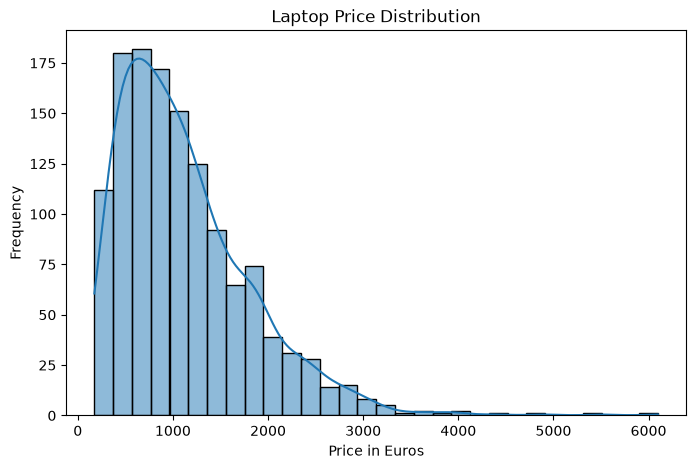

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price_euros'], bins=30, kde=True)

plt.title("Laptop Price Distribution")
plt.xlabel("Price in Euros")
plt.ylabel("Frequency")

plt.show()

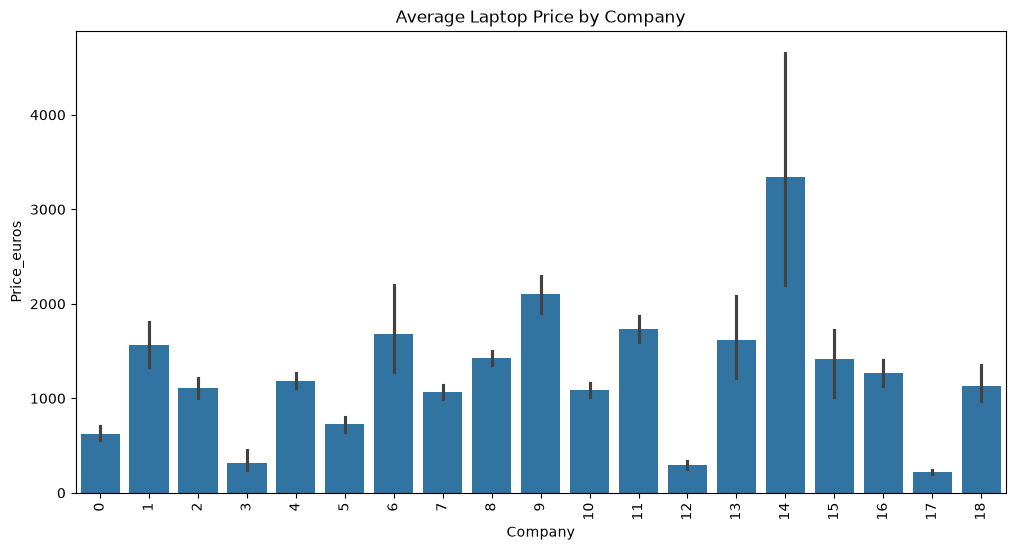

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    x="Company",
    y="Price_euros",
    data=df
)

plt.xticks(rotation=90)
plt.title("Average Laptop Price by Company")
plt.show()

In [50]:
print(df.columns.tolist())

['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros']


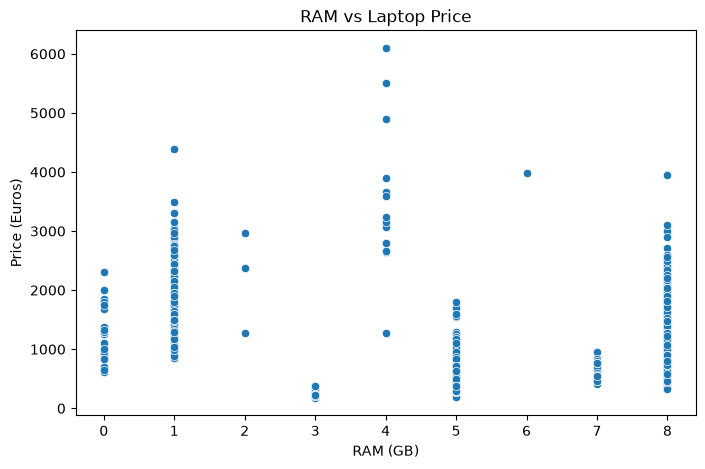

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Ram", y="Price_euros", data=df)

plt.title("RAM vs Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (Euros)")

plt.show()

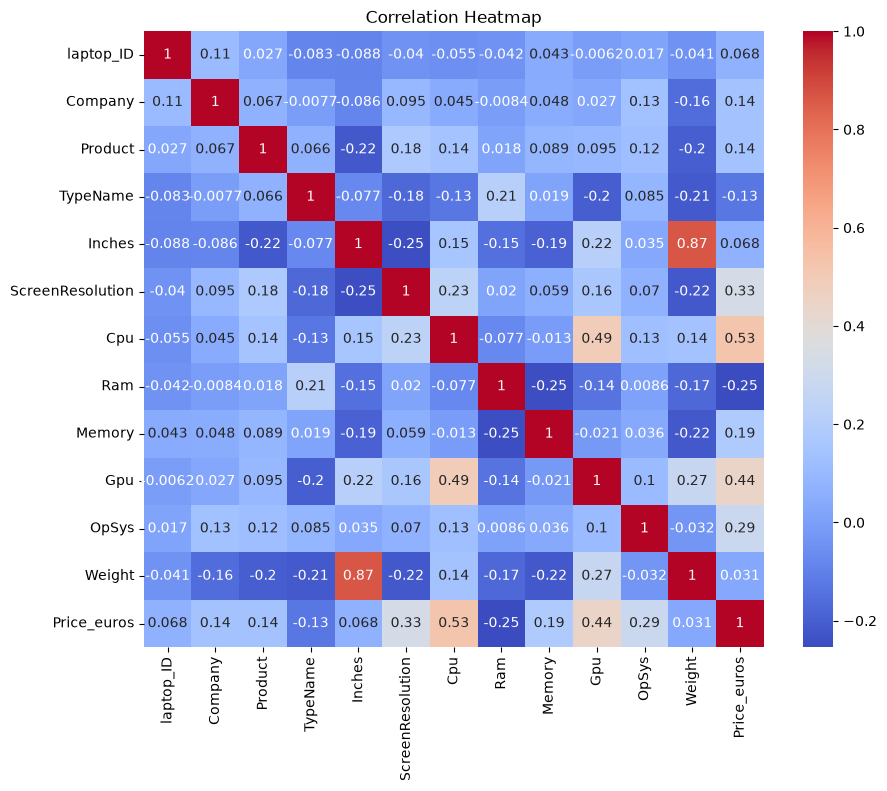

In [52]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

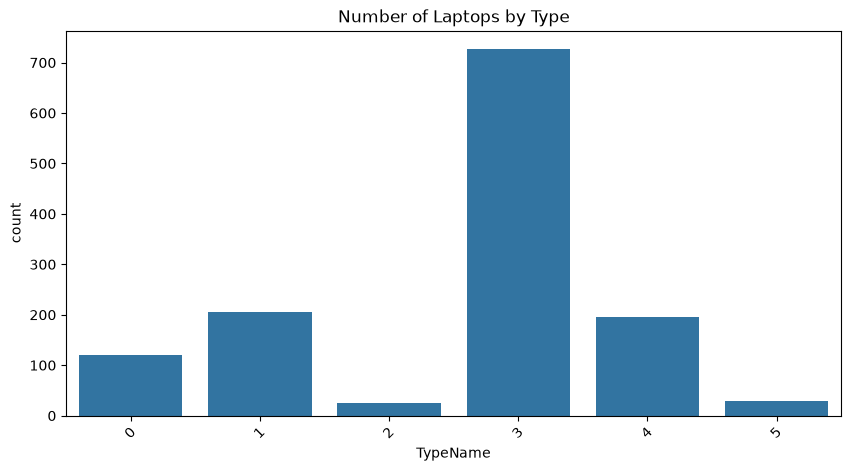

In [53]:
plt.figure(figsize=(10,5))

sns.countplot(x="TypeName", data=df)

plt.xticks(rotation=45)

plt.title("Number of Laptops by Type")

plt.show()

In [54]:
print("EDA completed successfully")

EDA completed successfully


question 4

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

In [56]:
df = pd.read_csv("cleaned_laptop_price.csv")

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,1,300,4,13.3,23,65,8,4,58,8,38,1339.69
1,2,1,301,4,13.3,1,63,8,2,51,8,35,898.94
2,3,7,50,3,15.6,8,74,8,16,53,4,74,575.00
3,4,1,300,4,15.4,25,85,1,29,9,8,71,2537.45
4,5,1,300,4,13.3,23,67,8,16,59,8,38,1803.60


In [57]:
label_encoders = {}

categorical_cols = ['Company', 'Product', 'TypeName',
                    'ScreenResolution', 'Cpu',
                    'Memory', 'Gpu', 'OpSys']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


In [59]:
print(df.dtypes)

laptop_ID             int64
Company               int64
Product               int64
TypeName              int64
Inches              float64
ScreenResolution      int64
Cpu                   int64
Ram                   int64
Memory                int64
Gpu                   int64
OpSys                 int64
Weight                int64
Price_euros         float64
dtype: object


In [60]:
from sklearn.model_selection import train_test_split
import joblib

# Features and Target
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1303, 12)
Target Shape: (1303,)


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (1042, 12)
Testing Data : (261, 12)


In [62]:
joblib.dump((X_train, X_test, y_train, y_test), "train_test_split.pkl")

print("Train-test split saved successfully.")

Train-test split saved successfully.


question 5

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import numpy as np

In [65]:
# Create StandardScaler object
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [66]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [67]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [68]:
y_pred = model.predict(X_test_scaled)

print("Prediction completed.")

Prediction completed.


In [69]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 444.0807173870882
Mean Squared Error  : 418332.2987904414
Root Mean Squared Error : 646.7861306416839
R² Score : 0.17639209926646027


In [70]:
joblib.dump(model, "linear_regression_model.pkl")

print("Model saved successfully.")

Model saved successfully.


question 6

In [71]:
import matplotlib.pyplot as plt

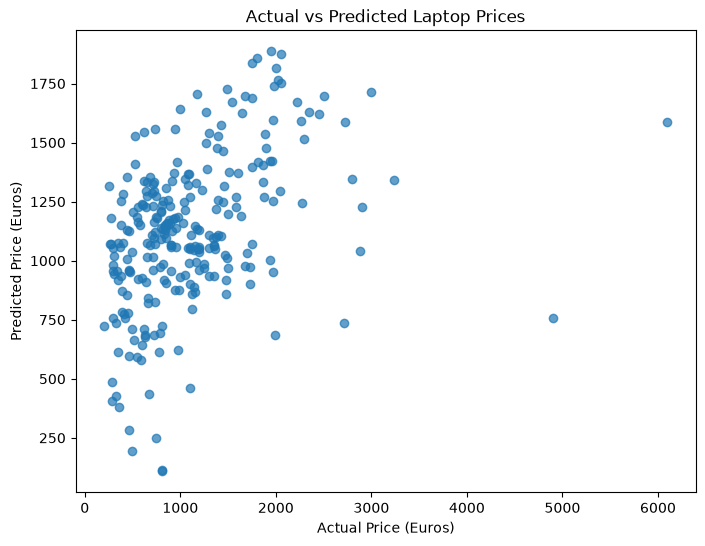

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Price (Euros)")
plt.ylabel("Predicted Price (Euros)")
plt.title("Actual vs Predicted Laptop Prices")

plt.show()

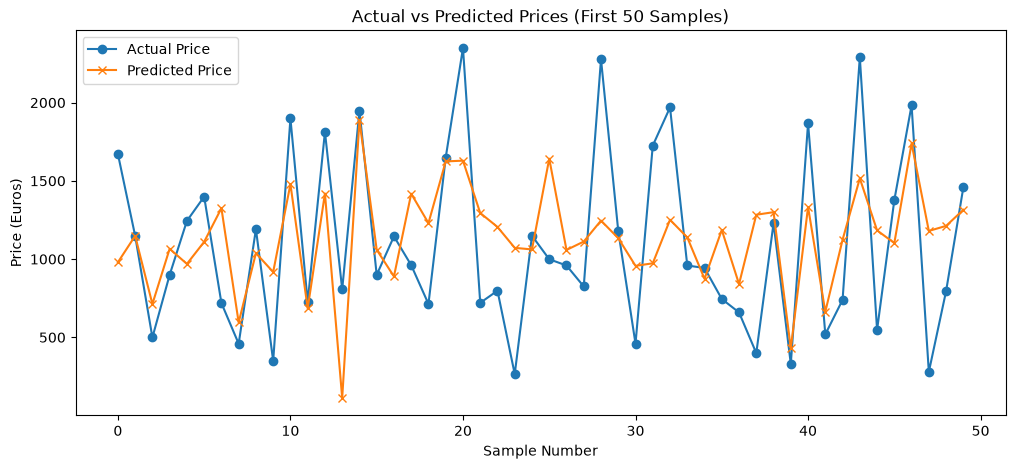

In [73]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:50], label="Actual Price", marker='o')
plt.plot(y_pred[:50], label="Predicted Price", marker='x')

plt.title("Actual vs Predicted Prices (First 50 Samples)")
plt.xlabel("Sample Number")
plt.ylabel("Price (Euros)")
plt.legend()

plt.show()

In [74]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1672.00,979.402515
1,1149.00,1148.228025
2,499.00,712.753664
3,899.00,1065.888762
4,1244.00,969.056818
5,1398.99,1110.230549
6,719.00,1325.260233
7,459.00,594.869783
8,1191.00,1037.965764
9,349.00,917.321619


In [75]:
comparison.to_csv("prediction_results.csv", index=False)

print("Prediction results saved successfully.")

Prediction results saved successfully.


question 7

In [76]:
import pandas as pd
import joblib

In [77]:
model = joblib.load("linear_regression_model.pkl")
scaler = joblib.load("scaler.pkl")

In [78]:
new_laptop = pd.DataFrame({
    'laptop_ID': [1304],
    'Company': [3],
    'Product': [120],
    'TypeName': [2],
    'Inches': [15.6],
    'ScreenResolution': [5],
    'Cpu': [40],
    'Ram': [8],
    'Memory': [25],
    'Gpu': [35],
    'OpSys': [2],
    'Weight': [2]
})

In [79]:
new_laptop_scaled = scaler.transform(new_laptop)

In [80]:
predicted_price = model.predict(new_laptop_scaled)

print("Predicted Laptop Price: €", round(predicted_price[0], 2))

Predicted Laptop Price: € 427.3


question 8

In [81]:
import joblib

In [82]:
joblib.dump(model, "../models/laptop_price_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [83]:
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.
